In [ ]:
# ! pip -q install "datasets==3.6.0"
# ! pip install pyannote.audio==4.0.3
# ! pip install numpy==2.0
# ! pip uninstall -y torchvision torchaudio torch
# ! pip cache purge
# ! pip install --no-cache-dir torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0 --index-url https://download.pytorch.org/whl/cu128


In [ ]:
from IPython.display import Audio as IPythonAudio, display, Markdown

import numpy as np
from scipy.io import wavfile
import torch
from scipy.io import wavfile
from tqdm import tqdm
import pandas as pd

from pyannote.audio import Pipeline
from pyannote.audio.pipelines.utils.hook import ProgressHook

from utils.hf_preprocessing import get_alignment_dataframe, prepare_alignment_dataset

/home/mila/g/guzmand/scratch/.conda/envs/ReadAlongs/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mila/g/guzmand/scratch/.conda/envs/ReadAlongs/lib/python3.10/site-packages/speechbrain/utils/torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()


- In Arabic there are at least two speakers, at least one in the Old Testament and at least other in the New Testament
- In Igbo there are at least two speakers, at least one in the Old Testament and at least other in the New Testament

In [ ]:
# ! rm -rf ~/.cache/huggingface/datasets/
# ! rm -rf ~/.cache/huggingface/hub/datasets--davidguzmanr--bible-tts-resources

# Dataset



In [2]:
LANGUAGE = "Igbo"

In [3]:
alignment_df = get_alignment_dataframe(LANGUAGE, base_dir="data/audios")
ds = prepare_alignment_dataset(alignment_df)
ds[0]

👀 ─ Found 30828 <text, audio> pairs
 · Checking if audio is readable...
😊 Found no unreadable audio files
 · Reading audio duration...
👀 ─ Found a total of 100.08 hours of readable data
 · Get transcript length...
 · Get num feature vectors...
👀 ┬ Found 361 audio clips over 30.0 seconds long
   └ Marking 4.50 hours of data as TOO_LONG
👀 ┬ Found 10 transcripts under 10 characters long
   └ Marking 0.01 hours of data as TOO_SHORT_TRANS
 · Get ratio (num_feats / transcript_len)...
👀 ┬ Found 13 <text, audio> pairs with more text than audio (bad for CTC)
   └ Marking 0.02 hours of data as OFFENDING_DATA
 · Calculating ratio (audio_len : transcript_len)...
👀 ┬ Found 433 <text, audio> pairs more than 3.0 standard deviations from the mean
   └ Marking 1.09 hours of data as NON_NORMAL
🎉 ┬ 30011 samples (94.46 hours) labeled as BEST
   └ Label distribution:
      - BEST: 30011
      - NON_NORMAL: 433
      - TOO_LONG: 361
      - OFFENDING_DATA: 13
      - TOO_SHORT_TRANS: 10


{'audio': {'path': 'data/audios/Igbo/Alignment/2 Peter/2PE_001_Verse_001.wav',
  'array': array([0., 0., 0., ..., 0., 0., 0.]),
  'sampling_rate': 48000},
 'text': 'Ọ bụ Saimọn Pita, odibo na onyeozi nke Jisọs Kraịst, Na-edegara ndị niile anyị na ha ketara otu ụdị okwukwe a dị oke ọnụahịa, nʼime ezi omume nke Chineke na Onye nzọpụta anyị Jisọs Kraịst akwụkwọ ozi a:',
 'testament': 'New Testament',
 'book': '2 Peter',
 'chapter': '001',
 'verse': '001',
 'duration_seconds': 17.9}

In [4]:
sample = ds[10]

display(Markdown(f"""
**Testament:** {sample['testament']}
**Book:** {sample['book']}
**Chapter:** {sample['chapter']}
**Verse:** {sample['verse']}
**Duration:** {sample['duration_seconds']}s

> {sample['text']}
"""))

display(
    IPythonAudio(
        data=sample["audio"]["array"],
        rate=sample["audio"]["sampling_rate"]
    )
)

## pyannote/speaker-diarization-precision-2

In [5]:
# # Precision-2 premium speaker diarization service
# pipeline = Pipeline.from_pretrained(
#     "pyannote/speaker-diarization-precision-2",
#     token="sk_aeac55a78ab2480889a932bf6b43f656"
# )

# # send pipeline to GPU (when available)
# pipeline.to(torch.device("cuda"))

In [6]:
# output = pipeline(output_path)  # runs on pyannoteAI servers

# # print the result
# for turn, speaker in output.speaker_diarization:
#     print(f"start={turn.start:.1f}s stop={turn.end:.1f}s {speaker}")

# output.speaker_diarization

# Speaker identification by book

In [7]:
df = ds.remove_columns("audio").to_pandas()
df["book"].value_counts()

book
Psalms      2447
Genesis     1525
Jeremiah    1361
Isaiah      1286
Numbers     1285
            ... 
Philemon      25
Jude          25
Obadiah       21
3 John        15
2 John        13
Name: count, Length: 66, dtype: int64

In [ ]:
# Precision-2 premium speaker diarization service
pipeline = Pipeline.from_pretrained(
    "pyannote/speaker-diarization-precision-2",
    token="<token>"
)

# send pipeline to GPU (when available)
pipeline.to(torch.device("cuda"))

In [9]:
# Get the first sample from each book
first_samples = {}
print("Finding first sample from each book...")
for sample in tqdm(ds, desc="Processing samples"):
    book = sample["book"]
    if book not in first_samples:
        first_samples[book] = sample

Finding first sample from each book...


Processing samples: 100%|██████████| 30011/30011 [02:16<00:00, 219.86it/s]


In [10]:
# samples = [first_samples[book] for book in first_samples.keys()]
# print(f"\nFound {len(samples)} books")

# # Get sampling rate and verify all samples have the same rate
# sampling_rate = samples[0]["audio"]["sampling_rate"]
# for sample in samples:
#     assert sample["audio"]["sampling_rate"] == sampling_rate, \
#         f"Sampling rate mismatch: expected {sampling_rate}, got {sample['audio']['sampling_rate']} for {sample['book']}"

# print(f"✓ All samples have consistent sampling rate: {sampling_rate} Hz")

# # Concatenate all audio arrays
# print("Concatenating audio...")
# concatenated_audio = np.concatenate([
#     sample["audio"]["array"]
#     for sample in tqdm(samples, desc="Concatenating")
# ])

# # Save as WAV file
# output_file = f"diarization/concatenated_bible_books_{LANGUAGE}.wav"
# print(f"Saving to {output_file}...")
# wavfile.write(output_file, sampling_rate, concatenated_audio.astype(np.float32))

# print(f"\n✓ Saved concatenated audio to {output_file}")
# print(f"Total duration: {len(concatenated_audio) / sampling_rate:.2f} seconds")
# print(f"Books included ({len(samples)}): {[s['book'] for s in samples]}")

# # Create DataFrame with timing information
# df_data = []
# cumulative_time = 0.0

# for sample in samples:
#     duration = sample["duration_seconds"]
#     start_time = cumulative_time
#     stop_time = cumulative_time + duration

#     df_data.append({
#         'book': sample['book'],
#         'testament': sample['testament'],
#         'chapter': sample['chapter'],
#         'verse': sample['verse'],
#         'text': sample['text'],
#         'duration': f"{duration:.1f}s",
#         'start': f"{start_time:.1f}s",
#         'stop': f"{stop_time:.1f}s"
#     })

#     cumulative_time = stop_time

# df = pd.DataFrame(df_data)
# df.to_csv(f"diarization/samples_{LANGUAGE}.csv", index=False)
# df

In [11]:
SILENCE_DURATION = 1.0  # seconds between each audio

samples = [first_samples[book] for book in first_samples.keys()]
print(f"\nFound {len(samples)} books")

# Get sampling rate and verify all samples have the same rate
sampling_rate = samples[0]["audio"]["sampling_rate"]
for sample in samples:
    assert sample["audio"]["sampling_rate"] == sampling_rate, \
        f"Sampling rate mismatch: expected {sampling_rate}, got {sample['audio']['sampling_rate']} for {sample['book']}"

print(f"✓ All samples have consistent sampling rate: {sampling_rate} Hz")

# Create silence array
silence_samples = np.zeros(int(SILENCE_DURATION * sampling_rate), dtype=np.float32)

# Concatenate all audio arrays with silence between them
print("Concatenating audio...")
audio_pieces = []
for i, sample in enumerate(tqdm(samples, desc="Concatenating")):
    audio_pieces.append(sample["audio"]["array"])
    if i < len(samples) - 1:  # Add silence between audios, not after the last
        audio_pieces.append(silence_samples)

concatenated_audio = np.concatenate(audio_pieces)

# Save as WAV file
output_file = f"diarization/concatenated_bible_books_{LANGUAGE}_with_silence.wav"
print(f"Saving to {output_file}...")
wavfile.write(output_file, sampling_rate, concatenated_audio.astype(np.float32))

print(f"\n✓ Saved concatenated audio to {output_file}")
print(f"Total duration: {len(concatenated_audio) / sampling_rate:.2f} seconds")
print(f"Books included ({len(samples)}): {[s['book'] for s in samples]}")

# Create DataFrame with timing information
df_data = []
cumulative_time = 0.0

for i, sample in enumerate(samples):
    duration = sample["duration_seconds"]
    start_time = cumulative_time
    # Include the 0.5s silence in stop time (except for the last audio)
    silence = SILENCE_DURATION if i < len(samples) - 1 else 0.0
    stop_time = cumulative_time + duration + silence

    df_data.append({
        'book': sample['book'],
        'testament': sample['testament'],
        'chapter': sample['chapter'],
        'verse': sample['verse'],
        'text': sample['text'],
        'duration': f"{duration:.1f}s",
        'start': f"{start_time:.1f}s",
        'stop': f"{stop_time:.1f}s"
    })

    cumulative_time = stop_time

df = pd.DataFrame(df_data)
df.to_csv(f"diarization/samples_{LANGUAGE}_with_silence.csv", index=False)
df


Found 66 books
✓ All samples have consistent sampling rate: 48000 Hz
Concatenating audio...


Concatenating: 100%|██████████| 66/66 [00:00<00:00, 766825.66it/s]

Saving to diarization/concatenated_bible_books_Igbo_with_silence.wav...



✓ Saved concatenated audio to diarization/concatenated_bible_books_Igbo_with_silence.wav
Total duration: 894.53 seconds
Books included (66): ['2 Peter', '1 John', '1 Corinthians', '1 Peter', '2 John', '1 Timothy', '1 Thessalonians', '2 Corinthians', '2 Thessalonians', '2 Timothy', '3 John', 'Acts', 'Colossians', 'Ephesians', 'Galatians', 'Hebrews', 'James', 'John', 'Jude', 'Luke', 'Mark', 'Matthew', 'Philemon', 'Philippians', 'Revelation', 'Romans', 'Titus', '1 Chronicles', '1 Kings', '1 Samuel', '2 Chronicles', '2 Kings', '2 Samuel', 'Amos', 'Daniel', 'Deuteronomy', 'Ecclesiastes', 'Esther', 'Exodus', 'Ezekiel', 'Ezra', 'Genesis', 'Habakkuk', 'Haggai', 'Hosea', 'Isaiah', 'Jeremiah', 'Job', 'Joel', 'Jonah', 'Joshua', 'Judges', 'Lamentations', 'Leviticus', 'Malachi', 'Micah', 'Nahum', 'Nehemiah', 'Numbers', 'Obadiah', 'Proverbs', 'Psalms', 'Ruth', 'Song of Songs', 'Zechariah', 'Zephaniah']


,book,testament,chapter,verse,text,duration,start,stop
0,2 Peter,New Testament,001,001,"Ọ bụ Saimọn Pita, odibo na onyeozi nke Jisọs K...",17.9s,0.0s,18.9s
1,1 John,New Testament,001,001,Ihe anyị na-edere unu banyere ya bụ ihe ahụ na...,16.6s,18.9s,36.5s
2,1 Corinthians,New Testament,001,001,"Pọl, onye a kpọrọ ịbụ onyeozi Jisọs Kraịst sit...",10.3s,36.5s,47.9s
3,1 Peter,New Testament,001,001,"Pita, onyeozi Jisọs Kraịst, Na-edegara unu ndị...",17.3s,47.9s,66.1s
4,2 John,New Testament,001,001,"Ọ bụ okenye ahụ, Na-edegara nwanyị ahụ onye Ch...",15.1s,66.1s,82.2s
...,...,...,...,...,...,...,...,...
61,Psalms,Old Testament,001,001,"Onye ihe na-agara nke ọma ka mmadụ ahụ bụ, ony...",11.4s,815.9s,828.3s
62,Ruth,Old Testament,001,001,"Nʼoge ndị ahụ, mgbe ndị ikpe na-achị, oke ụnwụ...",20.3s,828.3s,849.6s
63,Song of Songs,Old Testament,001,001,Abụ nke abụ nke Solomọn. Onye a hụrụ nʼanya,5.7s,849.6s,856.3s
64,Zechariah,Old Testament,001,001,"Nʼọnwa nke asatọ, nʼafọ nke abụọ nke ọchịchị e...",13.2s,856.3s,870.5s


In [15]:
total_seconds = df["duration"].apply(lambda x: float(x.rstrip("s"))).sum()
minutes = int(total_seconds // 60)
seconds = total_seconds % 60
print(f"Total duration: {minutes}m {seconds:.1f}s")

Total duration: 13m 49.5s


In [16]:
df[["testament", "book"]].value_counts()

testament      book           
New Testament  1 Corinthians      1
               1 John             1
               1 Peter            1
               1 Thessalonians    1
               1 Timothy          1
                                 ..
Old Testament  Psalms             1
               Ruth               1
               Song of Songs      1
               Zechariah          1
               Zephaniah          1
Name: count, Length: 66, dtype: int64

/home/mila/g/guzmand/scratch/.conda/envs/ReadAlongs/lib/python3.10/site-packages/pyannote/audio/utils/reproducibility.py:74: ReproducibilityWarning: TensorFloat-32 (TF32) has been disabled as it might lead to reproducibility issues and lower accuracy.
It can be re-enabled by calling
   >>> import torch
   >>> torch.backends.cuda.matmul.allow_tf32 = True
   >>> torch.backends.cudnn.allow_tf32 = True
See https://github.com/pyannote/pyannote-audio/issues/1370 for more details.

  warnings.warn(
/home/mila/g/guzmand/scratch/.conda/envs/ReadAlongs/lib/python3.10/site-packages/pyannoteai/sdk/client.py:356: UserWarning: 
You are using pyannoteAI's temporary storage solution. Your file will be permanently deleted from our servers within 24hs. 
If you are running in production, we highly recommend to use your own storage to reduce network latency and obtain results faster. 
Please check our documentation at https://docs.pyannote.ai/ for more information.
  warnings.warn("""
/home/mila/g/guzmand

start=0.0s stop=1.5s SPEAKER_03
start=2.1s stop=5.1s SPEAKER_03
start=5.5s stop=9.6s SPEAKER_03
start=10.0s stop=11.1s SPEAKER_03
start=11.7s stop=13.6s SPEAKER_03
start=14.1s stop=17.3s SPEAKER_03
start=18.9s stop=21.5s SPEAKER_03
start=22.1s stop=25.4s SPEAKER_03
start=26.0s stop=27.5s SPEAKER_03
start=27.9s stop=29.5s SPEAKER_03
start=30.1s stop=31.7s SPEAKER_03
start=32.3s stop=35.0s SPEAKER_03
start=36.5s stop=37.1s SPEAKER_02
start=37.7s stop=40.2s SPEAKER_02
start=40.8s stop=42.6s SPEAKER_02
start=43.2s stop=44.8s SPEAKER_02
start=45.1s stop=46.2s SPEAKER_02
start=47.9s stop=50.5s SPEAKER_03
start=51.1s stop=53.7s SPEAKER_03
start=54.3s stop=55.8s SPEAKER_03
start=55.9s stop=58.1s SPEAKER_03
start=58.5s stop=59.6s SPEAKER_03
start=60.2s stop=61.5s SPEAKER_03
start=61.9s stop=62.7s SPEAKER_03
start=62.8s stop=65.0s SPEAKER_03
start=66.1s stop=67.3s SPEAKER_03
start=68.0s stop=70.8s SPEAKER_03
start=71.3s stop=72.6s SPEAKER_03
start=73.2s stop=75.9s SPEAKER_03
start=76.4s stop=77.

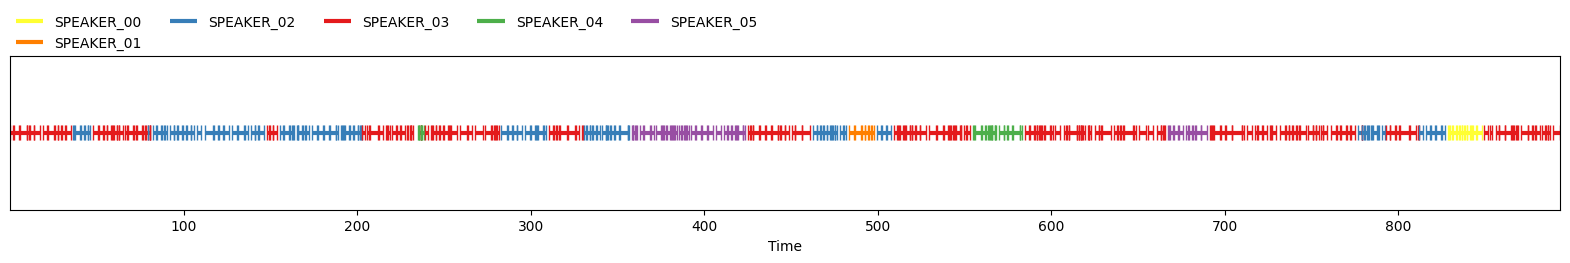

In [18]:
output = pipeline(output_file)  # runs on pyannoteAI servers

# print the result
for turn, speaker in output.speaker_diarization:
    print(f"start={turn.start:.1f}s stop={turn.end:.1f}s {speaker}")

output.speaker_diarization

In [19]:
len(output.speaker_diarization)

344

In [23]:
from collections import defaultdict


def parse_time(time_str):
    """Convert time string like '0.0s' to float seconds."""
    return float(time_str.rstrip("s"))


def assign_speaker_ids(df, diarization_output):
    """
    For each book's time window in df, find the speaker with the most
    accumulated speaking time according to the diarization output.
    """
    segments = [
        (turn.start, turn.end, speaker)
        for turn, speaker in diarization_output.speaker_diarization
    ]

    speaker_ids = []
    for _, row in df.iterrows():
        book_start = parse_time(row["start"])
        book_stop = parse_time(row["stop"])

        speaker_time = defaultdict(float)
        for seg_start, seg_end, speaker in segments:
            overlap = max(0.0, min(seg_end, book_stop) - max(seg_start, book_start))
            if overlap > 0:
                speaker_time[speaker] += overlap

        dominant = max(speaker_time, key=speaker_time.get) if speaker_time else None
        speaker_ids.append(dominant)

    return speaker_ids


df["speaker_id"] = assign_speaker_ids(df, output)
df

,book,testament,chapter,verse,text,duration,start,stop,speaker_id
0,2 Peter,New Testament,001,001,"Ọ bụ Saimọn Pita, odibo na onyeozi nke Jisọs K...",17.9s,0.0s,18.9s,SPEAKER_03
1,1 John,New Testament,001,001,Ihe anyị na-edere unu banyere ya bụ ihe ahụ na...,16.6s,18.9s,36.5s,SPEAKER_03
2,1 Corinthians,New Testament,001,001,"Pọl, onye a kpọrọ ịbụ onyeozi Jisọs Kraịst sit...",10.3s,36.5s,47.9s,SPEAKER_02
3,1 Peter,New Testament,001,001,"Pita, onyeozi Jisọs Kraịst, Na-edegara unu ndị...",17.3s,47.9s,66.1s,SPEAKER_03
4,2 John,New Testament,001,001,"Ọ bụ okenye ahụ, Na-edegara nwanyị ahụ onye Ch...",15.1s,66.1s,82.2s,SPEAKER_03
...,...,...,...,...,...,...,...,...,...
61,Psalms,Old Testament,001,001,"Onye ihe na-agara nke ọma ka mmadụ ahụ bụ, ony...",11.4s,815.9s,828.3s,SPEAKER_02
62,Ruth,Old Testament,001,001,"Nʼoge ndị ahụ, mgbe ndị ikpe na-achị, oke ụnwụ...",20.3s,828.3s,849.6s,SPEAKER_00
63,Song of Songs,Old Testament,001,001,Abụ nke abụ nke Solomọn. Onye a hụrụ nʼanya,5.7s,849.6s,856.3s,SPEAKER_03
64,Zechariah,Old Testament,001,001,"Nʼọnwa nke asatọ, nʼafọ nke abụọ nke ọchịchị e...",13.2s,856.3s,870.5s,SPEAKER_03


In [24]:
df["speaker_id"].value_counts()

speaker_id
SPEAKER_03    33
SPEAKER_02    20
SPEAKER_05     8
SPEAKER_04     3
SPEAKER_01     1
SPEAKER_00     1
Name: count, dtype: int64

In [ ]:
audio = first_samples["2 Peter"]["audio"]
IPythonAudio(data=audio["array"], rate=audio["sampling_rate"])

In [26]:
sample_speaker

book                                                    2 Peter
testament                                         New Testament
chapter                                                     001
verse                                                       001
text          Ọ bụ Saimọn Pita, odibo na onyeozi nke Jisọs K...
duration                                                  17.9s
start                                                      0.0s
stop                                                      18.9s
speaker_id                                           SPEAKER_03
Name: 0, dtype: object

In [31]:
speaker_id = "SPEAKER_03"
sample_speaker = df[df["speaker_id"] == speaker_id].iloc[0]

audio = first_samples[sample_speaker["book"]]["audio"]

display(Markdown(f"""
**Speaker:** {speaker_id}
**Testament:** {sample_speaker['testament']}
**Book:** {sample_speaker['book']}
**Chapter:** {sample_speaker['chapter']}
**Verse:** {sample_speaker['verse']}
**Duration:** {sample_speaker['duration']}

> {sample_speaker['text']}
"""))

display(IPythonAudio(data=audio["array"], rate=audio["sampling_rate"]))


**Speaker:** SPEAKER_03
**Testament:** New Testament
**Book:** 2 Peter
**Chapter:** 001
**Verse:** 001
**Duration:** 17.9s

> Ọ bụ Saimọn Pita, odibo na onyeozi nke Jisọs Kraịst, Na-edegara ndị niile anyị na ha ketara otu ụdị okwukwe a dị oke ọnụahịa, nʼime ezi omume nke Chineke na Onye nzọpụta anyị Jisọs Kraịst akwụkwọ ozi a:


In [32]:
speaker_id = "SPEAKER_02"
sample_speaker = df[df["speaker_id"] == speaker_id].iloc[0]

audio = first_samples[sample_speaker["book"]]["audio"]

display(Markdown(f"""
**Speaker:** {speaker_id}
**Testament:** {sample_speaker['testament']}
**Book:** {sample_speaker['book']}
**Chapter:** {sample_speaker['chapter']}
**Verse:** {sample_speaker['verse']}
**Duration:** {sample_speaker['duration']}

> {sample_speaker['text']}
"""))

display(IPythonAudio(data=audio["array"], rate=audio["sampling_rate"]))


**Speaker:** SPEAKER_02
**Testament:** New Testament
**Book:** 1 Corinthians
**Chapter:** 001
**Verse:** 001
**Duration:** 10.3s

> Pọl, onye a kpọrọ ịbụ onyeozi Jisọs Kraịst site nʼọchịchọ Chineke, na nwanna anyị nwoke Sostenis,


In [ ]:
book_to_speaker_id = {}
for _, row in df.iterrows():
    book = row["book"]
    speaker_id = row["speaker_id"]
    book_to_speaker_id[book] = speaker_id
book_to_speaker_id

{'2 Peter': 'SPEAKER_03',
 '1 John': 'SPEAKER_03',
 '1 Corinthians': 'SPEAKER_02',
 '1 Peter': 'SPEAKER_03',
 '2 John': 'SPEAKER_03',
 '1 Timothy': 'SPEAKER_02',
 '1 Thessalonians': 'SPEAKER_02',
 '2 Corinthians': 'SPEAKER_02',
 '2 Thessalonians': 'SPEAKER_02',
 '2 Timothy': 'SPEAKER_02',
 '3 John': 'SPEAKER_03',
 'Acts': 'SPEAKER_02',
 'Colossians': 'SPEAKER_02',
 'Ephesians': 'SPEAKER_02',
 'Galatians': 'SPEAKER_02',
 'Hebrews': 'SPEAKER_03',
 'James': 'SPEAKER_03',
 'John': 'SPEAKER_04',
 'Jude': 'SPEAKER_03',
 'Luke': 'SPEAKER_03',
 'Mark': 'SPEAKER_03',
 'Matthew': 'SPEAKER_03',
 'Philemon': 'SPEAKER_02',
 'Philippians': 'SPEAKER_02',
 'Revelation': 'SPEAKER_03',
 'Romans': 'SPEAKER_02',
 'Titus': 'SPEAKER_02',
 '1 Chronicles': 'SPEAKER_05',
 '1 Kings': 'SPEAKER_05',
 '1 Samuel': 'SPEAKER_05',
 '2 Chronicles': 'SPEAKER_05',
 '2 Kings': 'SPEAKER_05',
 '2 Samuel': 'SPEAKER_05',
 'Amos': 'SPEAKER_03',
 'Daniel': 'SPEAKER_03',
 'Deuteronomy': 'SPEAKER_02',
 'Ecclesiastes': 'SPEAKER_02

In [35]:
ds = ds.map(lambda example: {"speaker_id": book_to_speaker_id[example["book"]]})
ds[0]

Map: 100%|██████████| 30011/30011 [00:01<00:00, 20131.88 examples/s]


{'audio': {'path': 'data/audios/Igbo/Alignment/2 Peter/2PE_001_Verse_001.wav',
  'array': array([0., 0., 0., ..., 0., 0., 0.]),
  'sampling_rate': 48000},
 'text': 'Ọ bụ Saimọn Pita, odibo na onyeozi nke Jisọs Kraịst, Na-edegara ndị niile anyị na ha ketara otu ụdị okwukwe a dị oke ọnụahịa, nʼime ezi omume nke Chineke na Onye nzọpụta anyị Jisọs Kraịst akwụkwọ ozi a:',
 'testament': 'New Testament',
 'book': '2 Peter',
 'chapter': '001',
 'verse': '001',
 'duration_seconds': 17.9,
 'speaker_id': 'SPEAKER_03'}